# L04 · Introduction to Linear Models

*Companion notebook to **Section 2.1 (Lecture 4)** of the LaTeX notes (`latex/main.pdf`). Run the cells top to bottom.*

In [1]:
# --- Setup: imports, fixed seed, and a relative path to the data/ folder ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(2024)          # fixed seed for reproducibility
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Find the project's data/ folder by walking up from the notebook's folder.
DATA = next(p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
print("data folder:", DATA)

data folder: /home/claude/LSM/data


## Theory recap
A **model** is a low-dimensional summary of how a response $y$ depends on an explanatory variable $x$; our first model is the line $y=a_1+a_2x$. *All models are wrong but some are useful.* Models are compared by splitting data into training / validation / test parts (about 60/20/20).

In [2]:
import statsmodels.formula.api as smf
from scipy import optimize

In [3]:
h = pd.read_csv(DATA / "Heights.csv")
print(h.shape); print(h.mean())       # 1375 pairs; means 62.45 and 63.75
h.head()

(1375, 2)
mheight    62.4528
dheight    63.7511
dtype: float64


,mheight,dheight
0,59.7,55.1
1,58.2,56.5
2,60.6,56.0
3,60.7,56.8
4,61.8,56.0


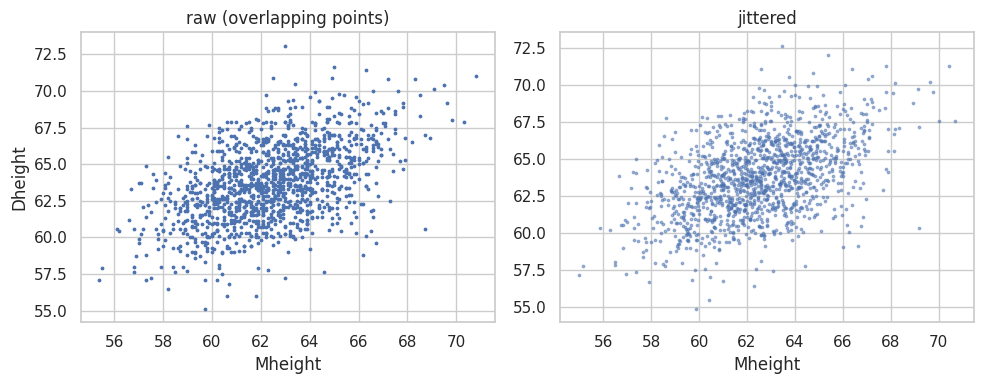

In [4]:
# Jitter plot: move each point by an independent U(-0.5, 0.5) amount in each coordinate
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(h.mheight, h.dheight, s=3); ax[0].set(title="raw (overlapping points)", xlabel="Mheight", ylabel="Dheight")
jx = h.mheight + rng.uniform(-.5, .5, len(h)); jy = h.dheight + rng.uniform(-.5, .5, len(h))
ax[1].scatter(jx, jy, s=3, alpha=.5); ax[1].set(title="jittered", xlabel="Mheight")
plt.tight_layout(); plt.show()

In [5]:
# Preview of Lecture 5: the least-squares line (regression to the mean: slope < 1)
fit = smf.ols("dheight ~ mheight", h).fit()
print(fit.params.round(4), "\nR^2 =", round(fit.rsquared, 4))

Intercept    29.9174
mheight       0.5417
dtype: float64 
R^2 = 0.2408


In [6]:
# 60 / 20 / 20 split (training / query / test) with the fixed generator
idx = rng.permutation(len(h)); n = len(h)
train, query, test = h.iloc[idx[:int(.6*n)]], h.iloc[idx[int(.6*n):int(.8*n)]], h.iloc[idx[int(.8*n):]]
print(len(train), len(query), len(test))
m = smf.ols("dheight ~ mheight", train).fit()
print(m.params.round(4))
print("test MSE:", np.mean((test.dheight - m.predict(test))**2).round(3))

825 275 275
Intercept    29.3259
mheight       0.5505
dtype: float64
test MSE: 5.509


## Try it yourself
1. Restrict to mothers with 58 ≤ Mheight ≤ 68 and redraw.
2. Compare the test MSE of the line with that of the constant model `ŷ = mean(train.dheight)`.